In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

num_cols = df.select_dtypes(include="number").columns
stats = df[num_cols].describe().T

stats['var'] = df[num_cols].var()
stats['IQR'] = stats['75%'] - stats['25%']
stats['mode'] = df[num_cols].mode().iloc[0]

stats = stats.rename(columns={'25%': 'Q1', '50%': 'median', '75%': 'Q3'})

cols_to_show = ['mean', 'median', 'mode', 'var', 'std', 'min', 'max', 'Q1', 'Q3', 'IQR']
pd.set_option('display.width', 1000)
print(stats[cols_to_show])
print("\n")

grouped_stats = df.groupby('species')[num_cols].agg(['mean', 'std'])
print(grouped_stats)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
                  mean  median  mode       var       std  min  max   Q1   Q3  IQR
sepal_length  5.843333    5.80   5.0  0.685694  0.828066  4.3  7.9  5.1  6.4  1.3
sepal_width   3.057333    3.00   3.0  0.189979  0.435866  2.0  4.4  2.8  3.3  0.5
petal_length  3.758000    4.35   1.4  3.116278  1.765298  1.0  6.9  1.6  5.1  3.5
petal_width   1.199333    1.30   0.2  0.581006  0.762238  0.1  2.5  0.3  1.8  1.5


           sepal_length           sepal_width           petal

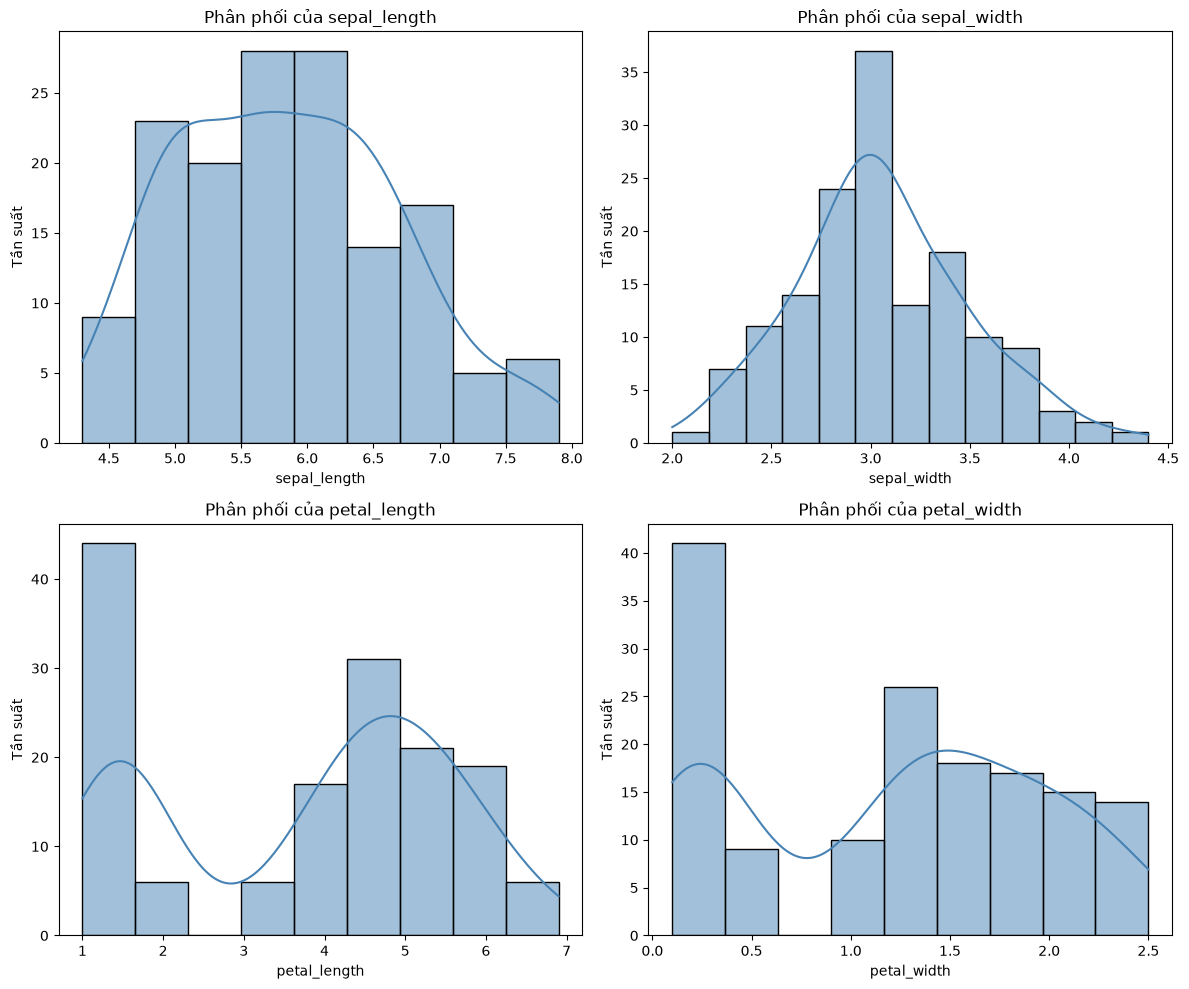

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Phân phối của {col}')
    axes[i].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

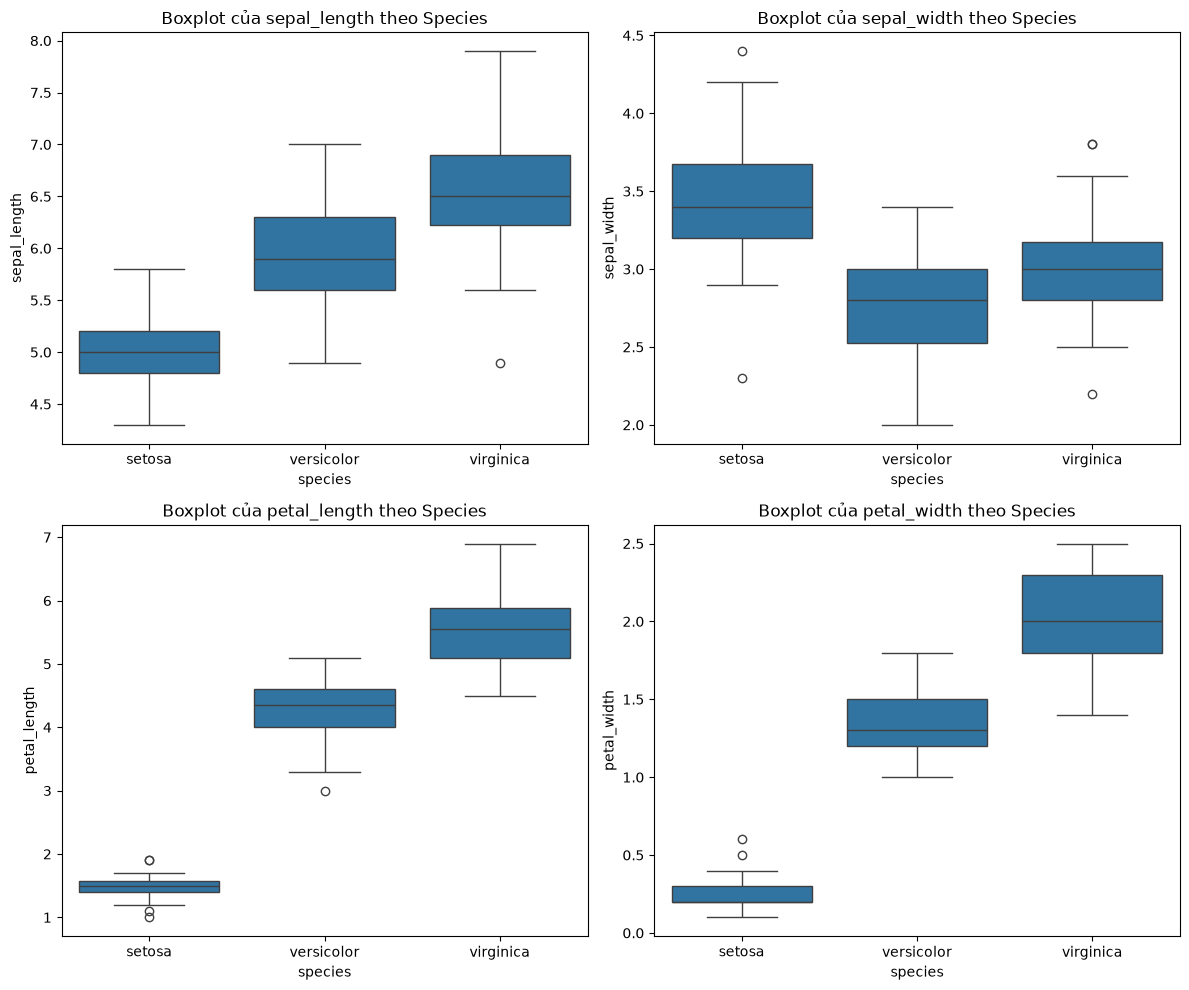

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot của {col} theo Species')

plt.tight_layout()
plt.show()

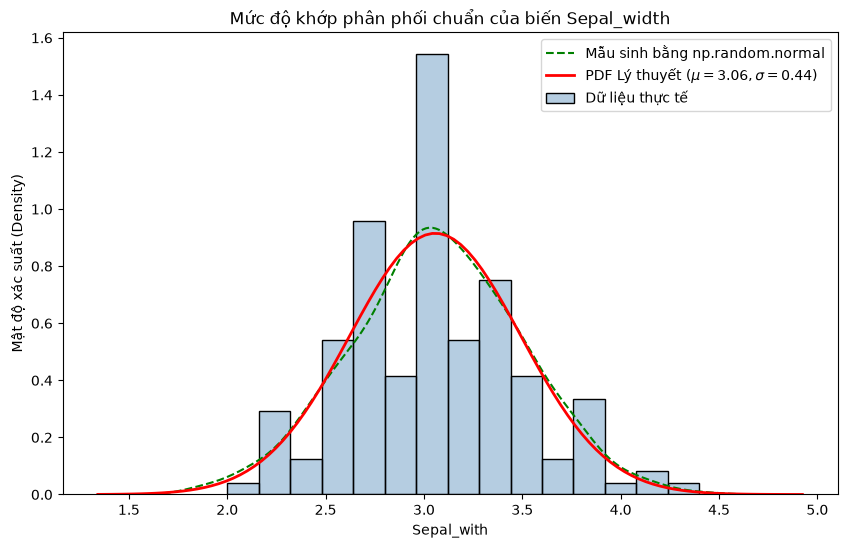

In [4]:
from scipy.stats import norm

data = df['sepal_width']

mu = data.mean()
sigma = data.std()

sample = np.random.normal(mu, sigma, size=1000)

plt.figure(figsize=(10, 6))

sns.histplot(data, bins=15, stat='density', alpha=0.4, label='Dữ liệu thực tế', color='steelblue')
sns.kdeplot(sample, color='green', linestyle='--', label='Mẫu sinh bằng np.random.normal')

xmin, xmax = plt.xlim()
x_pdf = np.linspace(xmin, xmax, 100)
y_pdf = norm.pdf(x_pdf, mu, sigma)
plt.plot(x_pdf, y_pdf, 'r-', lw=2, label=rf'PDF Lý thuyết ($\mu={mu:.2f}, \sigma={sigma:.2f}$)')

plt.title(f'Mức độ khớp phân phối chuẩn của biến Sepal_width')
plt.xlabel('Sepal_with')
plt.ylabel('Mật độ xác suất (Density)')
plt.legend()
plt.show()

In [5]:
cov_matrix = df[num_cols].cov()
print("Ma trận Hiệp phương sai (Covariance)")
print(cov_matrix)

corr_matrix = df[num_cols].corr()
print("\nMa trận Tương quan (Correlation)")
print(corr_matrix)

Ma trận Hiệp phương sai (Covariance)
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

Ma trận Tương quan (Correlation)
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


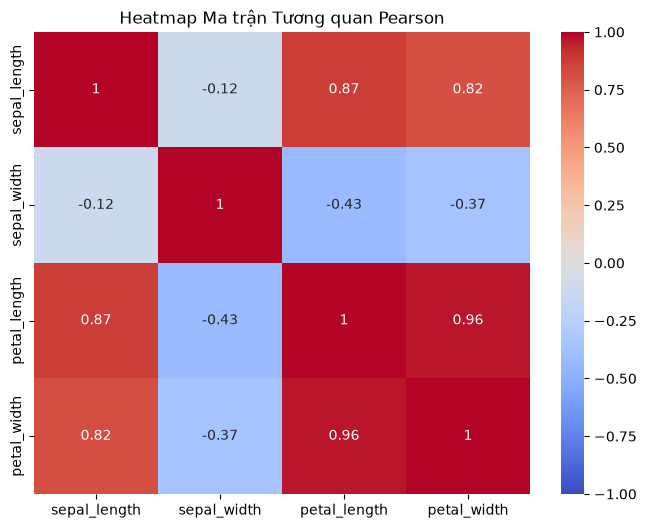

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Heatmap Ma trận Tương quan Pearson")
plt.show()

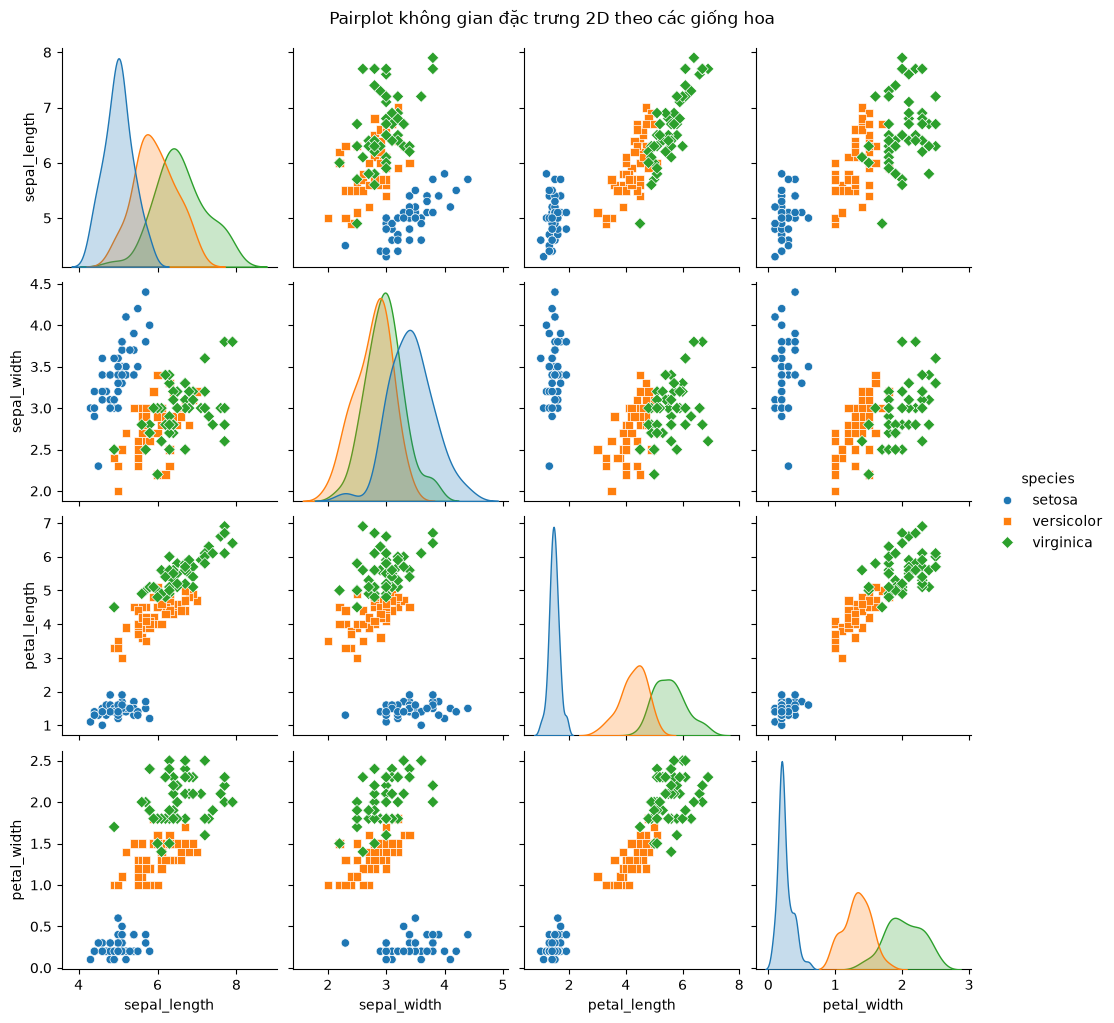

In [7]:
sns.pairplot(df, hue='species', markers=["o", "s", "D"])
plt.suptitle("Pairplot không gian đặc trưng 2D theo các giống hoa", y=1.02)
plt.show()

In [8]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05

P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos

print ( round ( P_B_given_pos , 4))

0.1667


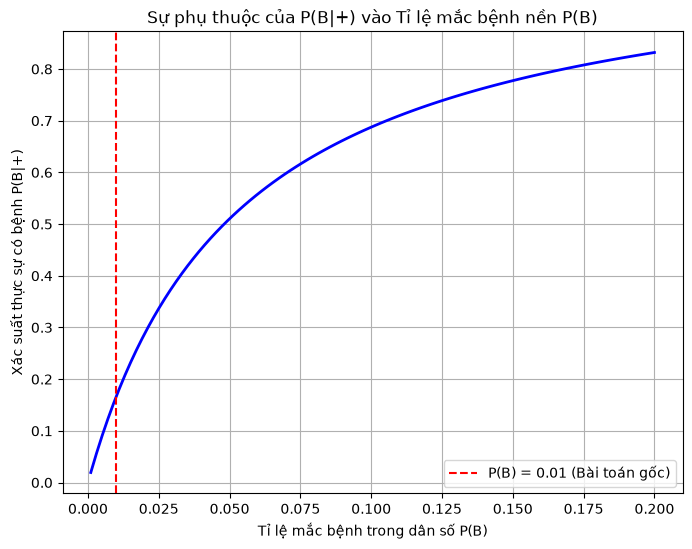

In [9]:
pB_arr = np.linspace(0.001, 0.2, 100)
p_notB_arr = 1 - pB_arr

p_pos_arr = (P_pos_givenB*pB_arr) + (P_pos_givnNB*p_notB_arr)
p_B_given_pos_array = (P_pos_givenB * pB_arr) / p_pos_arr

plt.figure(figsize=(8, 6))
plt.plot(pB_arr, p_B_given_pos_array, 'b-', lw=2)
plt.axvline(x=0.01, color='r', linestyle='--', label='P(B) = 0.01 (Bài toán gốc)')

plt.title('Sự phụ thuộc của P(B|+) vào Tỉ lệ mắc bệnh nền P(B)')
plt.xlabel('Tỉ lệ mắc bệnh trong dân số P(B)')
plt.ylabel('Xác suất thực sự có bệnh P(B|+)')
plt.grid(True)
plt.legend()
plt.show()